# DebugZero OpenEnv GRPO Training Notebook

This notebook trains against the actual DebugZero OpenEnv server. It installs the environment from GitHub, starts or connects to the OpenEnv API, smoke-tests `reset` / `step`, then uses TRL GRPO with an optional Unsloth fast path.

The important bit: rewards are computed by calling the live environment for model completions, not by scoring a static offline dataset.

## What This Notebook Produces

- A live OpenEnv smoke test.
- Baseline reward measurements.
- A short GRPO run using environment rewards.
- Trained-vs-baseline reward comparison.
- Plot files under `results/` for the README or presentation.

In [1]:
# Repository and environment configuration.
REPO_URL = "https://github.com/Ray-0906/DebugZero.git"
BRANCH = "main"

# Leave blank to start a local OpenEnv server inside Colab.
# Or set to a deployed Space URL, e.g. "https://the-fool-09-debugzero.hf.space".
# A browser page URL like "https://huggingface.co/spaces/The-Fool-09/debugZero" is also accepted and normalized.
REMOTE_OPENENV_URL = "https://the-fool-09-debugzero.hf.space"

# Training knobs. Keep these small for hackathon proof runs; increase for final evidence.
USE_UNSLOTH = True
MODEL_ID = "unsloth/Qwen2.5-Coder-1.5B-Instruct"
FALLBACK_MODEL_ID = "Qwen/Qwen2.5-Coder-1.5B-Instruct"
OUTPUT_DIR = "debugzero-openenv-grpo"
MAX_STEPS = 30
NUM_GENERATIONS = 2
DATASET_ROUNDS = 8
EVAL_SAMPLES = 4
RUN_TRAINING = True
RUN_BASELINE_EVAL = True

In [2]:
import importlib.util
import subprocess
import sys


def pip_install(*packages):
    print("Installing:", " ".join(packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

# Install runtime/training packages explicitly. The repo is installed with --no-deps
# so its experimental training pins cannot force incompatible Colab versions.
pip_install(
    "openenv-core[core]>=0.2.1",
    "datasets>=2.20.0",
    "trl>=0.20.0",
    "transformers>=4.51.0",
    "accelerate>=0.34.0",
    "peft>=0.12.0",
    "bitsandbytes>=0.43.0",
    "matplotlib>=3.8.0",
    "pandas>=2.0.0",
    "thefuzz[speedup]>=0.22.1",
    "uvicorn[standard]>=0.30.0",
    "requests>=2.31.0",
)

if USE_UNSLOTH:
    try:
        pip_install("unsloth")
    except Exception as exc:
        print("Unsloth install failed; the notebook will use native TRL fallback.")
        print(exc)

pip_install("--no-deps", f"git+{REPO_URL}@{BRANCH}")

Installing: openenv-core[core]>=0.2.1 datasets>=2.20.0 trl>=0.20.0 transformers>=4.51.0 accelerate>=0.34.0 peft>=0.12.0 bitsandbytes>=0.43.0 matplotlib>=3.8.0 pandas>=2.0.0 thefuzz[speedup]>=0.22.1 uvicorn[standard]>=0.30.0 requests>=2.31.0
Installing: unsloth
Installing: --no-deps git+https://github.com/Ray-0906/DebugZero.git@main


In [3]:
import atexit
import os
import re
import subprocess
import sys
import time
from urllib.parse import urlparse

import requests


def normalize_space_url(url: str) -> str:
    url = (url or "").strip().rstrip("/")
    if not url:
        return ""
    parsed = urlparse(url)
    if parsed.netloc == "huggingface.co" and parsed.path.startswith("/spaces/"):
        parts = parsed.path.strip("/").split("/")
        if len(parts) >= 3:
            owner, space = parts[1], parts[2]
            return f"https://{owner}-{space}.hf.space".lower()
    return url

REMOTE_OPENENV_URL = normalize_space_url(REMOTE_OPENENV_URL)

if REMOTE_OPENENV_URL:
    BASE_URL = REMOTE_OPENENV_URL
    server_process = None
else:
    BASE_URL = "http://127.0.0.1:8000"
    server_process = subprocess.Popen(
        [sys.executable, "-m", "debugZero.server.app", "--host", "127.0.0.1", "--port", "8000"],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    atexit.register(lambda: server_process and server_process.poll() is None and server_process.terminate())


def wait_for_openenv(base_url, timeout_s=120):
    deadline = time.time() + timeout_s
    last_error = None
    while time.time() < deadline:
        try:
            response = requests.get(f"{base_url}/schema", timeout=5)
            if response.status_code == 200:
                return response.json()
            last_error = f"HTTP {response.status_code}: {response.text[:200]}"
        except Exception as exc:
            last_error = exc
        time.sleep(2)

    if server_process and server_process.stdout:
        print("--- OpenEnv server output ---")
        print(server_process.stdout.read())
    raise RuntimeError(f"OpenEnv server did not become ready at {base_url}: {last_error}")

schema = wait_for_openenv(BASE_URL)
print("Connected to OpenEnv:", BASE_URL)
schema

Connected to OpenEnv: https://the-fool-09-debugzero.hf.space


{'action': {'additionalProperties': False,
  'description': 'Action for the DebugZero environment representing the Proposer or Solver inputs.',
  'properties': {'metadata': {'additionalProperties': True,
    'description': 'Additional metadata for the action',
    'title': 'Metadata',
    'type': 'object'},
   'role': {'description': "Role taking action: 'proposer' or 'solver'",
    'title': 'Role',
    'type': 'string'},
   'code': {'description': 'Code injected (by proposer) or fixed (by solver)',
    'title': 'Code',
    'type': 'string'}},
  'required': ['role', 'code'],
  'title': 'DebugzeroAction',
  'type': 'object'},
 'observation': {'additionalProperties': False,
  'description': 'Observation from the DebugZero environment following sandbox execution.',
  'properties': {'done': {'default': False,
    'description': 'Whether the episode has terminated',
    'title': 'Done',
    'type': 'boolean'},
   'reward': {'anyOf': [{'type': 'boolean'},
     {'type': 'integer'},
     {'typ

In [6]:
from debugZero.client import DebugzeroEnv
from debugZero.models import DebugzeroAction


def observation(result):
    return getattr(result, "observation", result)

with DebugzeroEnv(base_url=BASE_URL).sync() as env:
    reset_obs = observation(env.reset())
    print("Initial role:", reset_obs.role_next)
    print(reset_obs.current_code[:300])

    # This exact boundary bug should fail after the equality-at-threshold grader fix.
    # The current environment tests do not catch the 'distance <= threshold' bug.
    # For the smoke test, we'll introduce a syntax error instead to guarantee failure.
    buggy_code = reset_obs.current_code + "\nThis is a syntax error\n"
    prop_obs = observation(env.step(DebugzeroAction(role="proposer", code=buggy_code)))
    print("After proposer:", {"role_next": prop_obs.role_next, "tests_passed": prop_obs.tests_passed, "syntax_error": prop_obs.syntax_error})
    assert prop_obs.tests_passed is False or prop_obs.syntax_error is True, "Proposer should introduce a bug or syntax error for the smoke test."

    solve_obs = observation(env.step(DebugzeroAction(role="solver", code=reset_obs.current_code)))
    print("After solver:", {"role_next": solve_obs.role_next, "tests_passed": solve_obs.tests_passed, "syntax_error": solve_obs.syntax_error})
    assert solve_obs.tests_passed is True and solve_obs.syntax_error is False, "Clean solution should pass."

Initial role: proposer
def has_close_elements(numbers: list[float], threshold: float) -> bool:
    for idx, elem in enumerate(numbers):
        for idx2, elem2 in enumerate(numbers):
            if idx != idx2:
                distance = abs(elem - elem2)
                if distance < threshold:
                    return
After proposer: {'role_next': 'solver', 'tests_passed': False, 'syntax_error': True}
After solver: {'role_next': 'end', 'tests_passed': True, 'syntax_error': False}


In [8]:
import re
from datasets import Dataset

PROPOSER_PROMPT = """You are the Proposer in DebugZero.
Inject one realistic, syntax-valid bug into the clean Python function.
The mutated function must run but fail at least one environment test.
Prefer small human-like edits: boundary, comparison, operator, return-condition, or loop mistakes.
Return only the complete modified Python code inside a python code fence.

Clean function:
```python
{code}
```
"""

SOLVER_PROMPT = """You are the Solver in DebugZero.
Repair the buggy Python function so it passes the environment tests.
Return only the complete repaired Python code inside a python code fence.

Buggy function:
```python
{code}
```
"""


def extract_code(text):
    if isinstance(text, list):
        if text and isinstance(text[0], dict):
            text = text[0].get("content", "")
        else:
            text = "\n".join(map(str, text))
    text = str(text or "")
    match = re.search(r"```(?:python)?\s*(.*?)```", text, flags=re.DOTALL | re.IGNORECASE)
    return (match.group(1) if match else text).strip()


def deterministic_bug(clean_code):
    replacements = [
        ("distance < threshold", "distance <= threshold"),
        ("idx != idx2", "idx == idx2"),
        ("return True", "return False"),
        ("return False", "return True"),
    ]
    for old, new in replacements:
        if old in clean_code:
            return clean_code.replace(old, new, 1)
    return clean_code + "\n# BUG: intentionally left for solver\n"


def build_openenv_dataset(num_rounds=8):
    rows = []
    with DebugzeroEnv(base_url=BASE_URL).sync() as env:
        for episode in range(num_rounds):
            clean_obs = observation(env.reset())
            clean_code = clean_obs.current_code
            buggy_code = deterministic_bug(clean_code)

            rows.append({
                "prompt": PROPOSER_PROMPT.format(code=clean_code),
                "role": "proposer",
                "clean_code": clean_code,
                "buggy_code": "",
                "episode": episode,
            })
            rows.append({
                "prompt": SOLVER_PROMPT.format(code=buggy_code),
                "role": "solver",
                "clean_code": clean_code,
                "buggy_code": buggy_code,
                "episode": episode,
            })
    return Dataset.from_list(rows)

train_dataset = build_openenv_dataset(num_rounds=DATASET_ROUNDS)
print(train_dataset)
print(train_dataset[0]["prompt"][:500])


Dataset({
    features: ['prompt', 'role', 'clean_code', 'buggy_code', 'episode'],
    num_rows: 16
})
You are the Proposer in DebugZero.
Inject one realistic, syntax-valid bug into the clean Python function.
The mutated function must run but fail at least one environment test.
Prefer small human-like edits: boundary, comparison, operator, return-condition, or loop mistakes.
Return only the complete modified Python code inside a python code fence.

Clean function:
```python
def has_close_elements(numbers: list[float], threshold: float) -> bool:
    for idx, elem in enumerate(numbers):
        for


In [10]:
def proposer_reward(obs, submitted_code, clean_code):
    if obs.syntax_error:
        return -1.0
    if submitted_code.strip() == clean_code.strip():
        return -0.5
    return 1.0 if not obs.tests_passed else 0.0


def solver_reward(obs, submitted_code, clean_code):
    if obs.syntax_error:
        return -1.0
    if submitted_code.strip() == clean_code.strip() and obs.tests_passed:
        return 1.25
    return 1.0 if obs.tests_passed else 0.0


def _column(kwargs, singular, plural=None):
    if singular in kwargs and kwargs[singular] is not None:
        return kwargs[singular]
    if plural and plural in kwargs and kwargs[plural] is not None:
        return kwargs[plural]
    raise KeyError(f"Reward function missing dataset column '{singular}'. Available keys: {sorted(kwargs.keys())}")


def openenv_reward(*args, **kwargs):
    # TRL GRPO custom rewards receive prompts, completions, and all extra dataset columns.
    # Across versions this may arrive as positional args or keyword args, so parse defensively.
    completions = kwargs.get("completions")
    if completions is None:
        if len(args) >= 2:
            completions = args[1]
        elif len(args) == 1:
            completions = args[0]
        else:
            raise TypeError("Reward function did not receive completions.")

    roles = _column(kwargs, "role", "roles")
    clean_codes = _column(kwargs, "clean_code", "clean_codes")
    buggy_codes = kwargs.get("buggy_code", kwargs.get("buggy_codes", [""] * len(completions)))

    rewards = []
    with DebugzeroEnv(base_url=BASE_URL).sync() as env:
        for completion, sample_role, clean, bug in zip(completions, roles, clean_codes, buggy_codes):
            code = extract_code(completion)
            env.reset()
            if sample_role == "proposer":
                obs = observation(env.step(DebugzeroAction(role="proposer", code=code)))
                rewards.append(proposer_reward(obs, code, clean))
            elif sample_role == "solver":
                env.step(DebugzeroAction(role="proposer", code=bug))
                obs = observation(env.step(DebugzeroAction(role="solver", code=code)))
                rewards.append(solver_reward(obs, code, clean))
            else:
                rewards.append(0.0)
    return rewards

# Reward sanity checks against the live environment.
clean = train_dataset[0]["clean_code"]
buggy = deterministic_bug(clean)
print("proposer boundary bug reward:", openenv_reward([None], [f"```python\n{buggy}\n```"], role=["proposer"], clean_code=[clean], buggy_code=[""]))
print("solver clean repair reward:", openenv_reward([None], [f"```python\n{clean}\n```"], role=["solver"], clean_code=[clean], buggy_code=[buggy]))

proposer boundary bug reward: [0.0]
solver clean repair reward: [1.25]


In [11]:
import torch

HAS_UNSLOTH = False
if USE_UNSLOTH:
    try:
        from unsloth import FastLanguageModel, PatchFastRL, is_bfloat16_supported
        PatchFastRL("GRPO", FastLanguageModel)
        HAS_UNSLOTH = True
    except Exception as exc:
        print("Using native Transformers/TRL fallback because Unsloth is unavailable:")
        print(exc)
        HAS_UNSLOTH = False

if not HAS_UNSLOTH:
    is_bfloat16_supported = lambda: False

from trl import GRPOConfig, GRPOTrainer

if HAS_UNSLOTH:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_ID,
        max_seq_length=2048,
        load_in_4bit=True,
        fast_inference=False,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_alpha=16,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=3407,
    )
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(FALLBACK_MODEL_ID, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        FALLBACK_MODEL_ID,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True,
    )

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: UnslothBCOTrainer is already patched.
Unsloth: UnslothCPOTrainer is already patched.
Unsloth: UnslothDPOTrainer is already patched.
Unsloth: UnslothGKDTrainer is already patched.
Unsloth: UnslothGRPOTrainer is already patched.
Unsloth: UnslothKTOTrainer is already patched.
Unsloth: UnslothNashMDTrainer is already patched.
Unsloth: UnslothOnlineDPOTrainer is already patched.
Unsloth: UnslothORPOTrainer is already patched.
Unsloth: UnslothPPOTrainer is already patched.
Unsloth: UnslothPRMTrainer is already patched.
Unsloth: UnslothRewardTrainer is already patched.
Unsloth: UnslothRLOOTrainer is already patched.
Unsloth: UnslothSFTTrainer is already patched.
Unsloth: UnslothXPOTrainer is already patched.
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platfor

model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [12]:
def model_device(model):
    try:
        return next(model.parameters()).device
    except Exception:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def generate_completion(prompt, max_new_tokens=384):
    inputs = tokenizer(prompt, return_tensors="pt").to(model_device(model))
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)


def evaluate_policy(dataset, n=4):
    rows = [dataset[i] for i in range(min(n, len(dataset)))]
    completions = [generate_completion(row["prompt"]) for row in rows]
    rewards = openenv_reward(
        [row["prompt"] for row in rows],
        completions,
        role=[row["role"] for row in rows],
        clean_code=[row["clean_code"] for row in rows],
        buggy_code=[row["buggy_code"] for row in rows],
    )
    return rewards, completions

if RUN_BASELINE_EVAL:
    baseline_rewards, baseline_completions = evaluate_policy(train_dataset, n=EVAL_SAMPLES)
else:
    baseline_rewards, baseline_completions = [], []

print("Baseline rewards:", baseline_rewards)
if baseline_rewards:
    print("Baseline mean:", sum(baseline_rewards) / len(baseline_rewards))

Both `max_new_tokens` (=384) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

Baseline rewards: [0.0, 1.0, 0.0, 0.0]
Baseline mean: 0.25


In [13]:
import inspect


def make_grpo_config(**kwargs):
    supported = inspect.signature(GRPOConfig).parameters
    filtered = {key: value for key, value in kwargs.items() if key in supported}
    ignored = sorted(set(kwargs) - set(filtered))
    if ignored:
        print("Ignoring unsupported GRPOConfig args for this TRL version:", ignored)
    return GRPOConfig(**filtered)

training_args = make_grpo_config(
    output_dir=OUTPUT_DIR,
    max_steps=MAX_STEPS,
    learning_rate=5e-6,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_generations=NUM_GENERATIONS,
    max_prompt_length=1024,
    max_completion_length=384,
    logging_steps=1,
    save_steps=MAX_STEPS,
    report_to="none",
    bf16=bool(torch.cuda.is_available() and is_bfloat16_supported()),
    fp16=bool(torch.cuda.is_available() and not is_bfloat16_supported()),
    remove_unused_columns=False,
)

trainer_kwargs = dict(
    model=model,
    reward_funcs=[openenv_reward],
    args=training_args,
    train_dataset=train_dataset,
)

try:
    trainer = GRPOTrainer(processing_class=tokenizer, **trainer_kwargs)
except TypeError:
    trainer = GRPOTrainer(tokenizer=tokenizer, **trainer_kwargs)

if RUN_TRAINING:
    train_result = trainer.train()
    trainer.save_model(OUTPUT_DIR)
else:
    train_result = None
    print("RUN_TRAINING=False, trainer configured but not executed.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 16 | Num Epochs = 4 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'cache_implementation', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=384) and `max_length`(=32768) seem to have been set. `max_new_tokens` will 

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / openenv_reward / mean,rewards / openenv_reward / std
1,0.000000,0.125000,0.530330,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000003,0.125000,0.629153
2,-0.042833,0.125000,0.530330,363.250000,301.000000,384.000000,0.750000,301.000000,301.000000,301.000000,0.000004,0.125000,0.629153
3,0.084599,0.000000,0.707107,319.500000,192.000000,384.000000,0.500000,255.000000,192.000000,318.000000,0.000004,0.000000,0.816497
4,0.000000,0.000000,0.000000,232.500000,58.000000,384.000000,0.500000,81.000000,58.000000,104.000000,0.000004,0.000000,0.000000
5,0.000000,-0.125000,0.176777,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000004,-0.125000,0.250000
6,0.000000,0.000000,0.707107,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000005,0.000000,0.816497
7,0.000000,0.000000,0.000000,379.750000,367.000000,384.000000,0.750000,367.000000,367.000000,367.000000,0.000005,0.000000,1.154701
8,0.000000,0.250000,1.060660,384.000000,384.000000,384.000000,1.000000,0.000000,0.000000,0.000000,0.000004,0.250000,0.957427
9,0.055542,-0.125000,0.176777,332.000000,266.000000,384.000000,0.500000,280.000000,266.000000,294.000000,0.000004,-0.125000,0.250000
10,0.056488,0.250000,0.353553,337.500000,198.000000,384.000000,0.750000,198.000000,198.000000,198.000000,0.000006,0.250000,0.500000


Both `max_new_tokens` (=384) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=3

In [14]:
trained_rewards, trained_completions = evaluate_policy(train_dataset, n=EVAL_SAMPLES)
print("Baseline rewards:", baseline_rewards)
if baseline_rewards:
    print("Baseline mean:", sum(baseline_rewards) / len(baseline_rewards))
print("Trained rewards:", trained_rewards)
if trained_rewards:
    print("Trained mean:", sum(trained_rewards) / len(trained_rewards))

Both `max_new_tokens` (=384) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=3

Baseline rewards: [0.0, 1.0, 0.0, 0.0]
Baseline mean: 0.25
Trained rewards: [0.0, 1.0, 0.0, 0.0]
Trained mean: 0.25


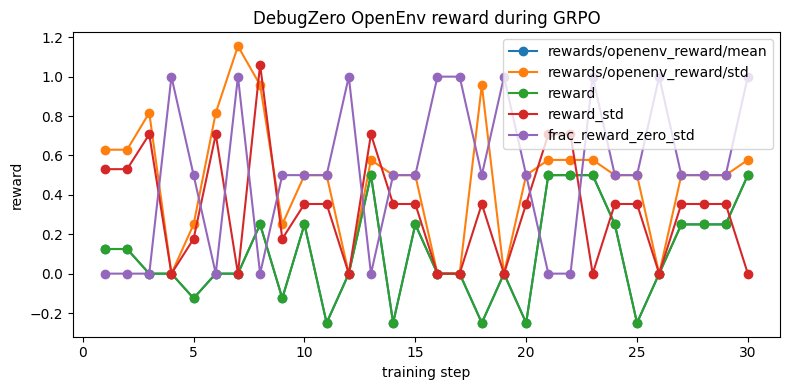

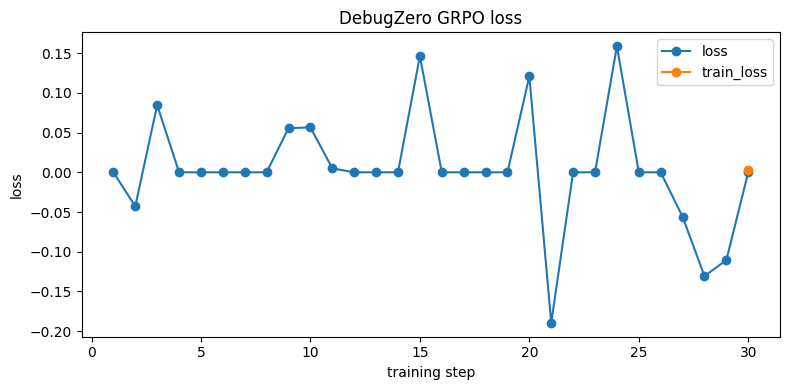

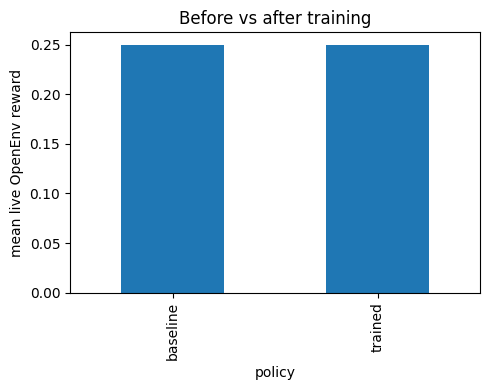

,phase,mean_reward
0,baseline,0.25
1,trained,0.25


In [15]:
import os

import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("results", exist_ok=True)
history = pd.DataFrame(getattr(trainer.state, "log_history", []))
history.to_csv("results/training_log.csv", index=False)

reward_cols = [col for col in history.columns if "reward" in col.lower()]
loss_cols = [col for col in history.columns if "loss" in col.lower()]

if "step" in history.columns and reward_cols:
    ax = history.plot(x="step", y=reward_cols, marker="o", figsize=(8, 4))
    ax.set_xlabel("training step")
    ax.set_ylabel("reward")
    ax.set_title("DebugZero OpenEnv reward during GRPO")
    plt.tight_layout()
    plt.savefig("results/reward_curve.png", dpi=160)
    plt.show()
else:
    print("No reward columns found in trainer history. Columns:", list(history.columns))

if "step" in history.columns and loss_cols:
    ax = history.plot(x="step", y=loss_cols, marker="o", figsize=(8, 4))
    ax.set_xlabel("training step")
    ax.set_ylabel("loss")
    ax.set_title("DebugZero GRPO loss")
    plt.tight_layout()
    plt.savefig("results/loss_curve.png", dpi=160)
    plt.show()
else:
    print("No loss columns found in trainer history. Columns:", list(history.columns))

comparison = pd.DataFrame({
    "phase": ["baseline", "trained"],
    "mean_reward": [
        sum(baseline_rewards) / len(baseline_rewards) if baseline_rewards else 0.0,
        sum(trained_rewards) / len(trained_rewards) if trained_rewards else 0.0,
    ],
})
ax = comparison.plot.bar(x="phase", y="mean_reward", legend=False, figsize=(5, 4))
ax.set_xlabel("policy")
ax.set_ylabel("mean live OpenEnv reward")
ax.set_title("Before vs after training")
plt.tight_layout()
plt.savefig("results/baseline_vs_trained_reward.png", dpi=160)
plt.show()
comparison

## Submission Note

After running the notebook, attach or commit the generated files under `results/` and link this notebook from the README. Judges should be able to see the GitHub install, OpenEnv smoke test, reward sanity checks, baseline-vs-trained comparison, and the plots.